# Local Outlier Factor (LOF)

LOF (Breunig et al., 2000) detects anomalies by comparing the **local density** of each point to the local density of its neighbors. A point is an outlier if it is in a region of much lower density than its neighbors.

---

## Table of Contents
1. [Motivation — Why Local Matters](#1-motivation)
2. [LOF Mathematics Step by Step](#2-math)
   - k-distance
   - Reachability Distance
   - Local Reachability Density
   - LOF Score
3. [Geometric Interpretation](#3-geometric)
4. [Choosing k (n_neighbors)](#4-choosing-k)
5. [LOF in Novelty Detection Mode](#5-novelty)
6. [LOF vs Isolation Forest vs DBSCAN](#6-comparison)
7. [Implementation from Scratch](#7-scratch)
8. [sklearn LOF on Real Data](#8-sklearn)
9. [Summary](#9-summary)

---
## 1. Motivation — Why Local Matters

### The Problem with Global Methods

Consider data with two clusters of very different densities:
- **Cluster A**: 100 points tightly packed in a radius of 0.5
- **Cluster B**: 100 points loosely packed in a radius of 5
- **Point X**: On the edge of Cluster B, distance 6 from Cluster B's center

A **global** method (like Isolation Forest or Mahalanobis Distance) might flag points on the edge of Cluster B as anomalies — their density is low globally. But relative to their neighborhood (Cluster B), they are perfectly normal!

### The LOF Insight

> An anomaly is a point that is much less dense than its neighbors — regardless of the global density.

LOF compares each point's density to its neighbors' densities. Points in dense clusters have density similar to their neighbors (LOF ≈ 1). Points in sparse areas surrounded by dense neighbors have LOF >> 1.

### Visual Example

- Normal point in a dense cluster: surrounded by similar-density neighbors → LOF ≈ 1
- Normal point in a sparse cluster: surrounded by similar-density neighbors → LOF ≈ 1 (even though globally sparse)
- True anomaly: in a low-density region surrounded by high-density neighborhoods → LOF >> 1

---
## 2. LOF Mathematics Step by Step

Let $D$ be the dataset, $d(A, B)$ be the distance between points $A$ and $B$, and $k$ be the number of neighbors.

### Step 1 — k-Distance

$$k\text{-dist}(A) = \text{distance from } A \text{ to its } k\text{-th nearest neighbor}$$

All points within this distance form the **k-neighborhood** of $A$:

$$N_k(A) = \{ B \in D \setminus \{A\} \mid d(A, B) \leq k\text{-dist}(A) \}$$

Note: $|N_k(A)| \geq k$ (may be larger due to ties at the boundary).

### Step 2 — Reachability Distance

$$\text{reach-dist}_k(A, B) = \max(k\text{-dist}(B),\; d(A, B))$$

This is the distance from $A$ to $B$, but floored by $B$'s k-distance.

**Why this smoothing?** Prevents very small distances from inflating density estimates when two points are very close together. It ensures that nearby points within $B$'s dense core all get the same effective distance ($B$'s k-distance).

### Step 3 — Local Reachability Density (lrd)

$$\text{lrd}_k(A) = \frac{|N_k(A)|}{\sum_{B \in N_k(A)} \text{reach-dist}_k(A, B)}$$

The inverse of the average reachability distance from $A$ to its neighbors.

- High $\text{lrd}$: $A$ is in a **dense** region (small reach-distances)
- Low $\text{lrd}$: $A$ is in a **sparse** region (large reach-distances)

### Step 4 — Local Outlier Factor

$$\text{LOF}_k(A) = \frac{\sum_{B \in N_k(A)} \frac{\text{lrd}_k(B)}{\text{lrd}_k(A)}}{|N_k(A)|} = \frac{\overline{\text{lrd}_k(\text{neighbors of }A)}}{\text{lrd}_k(A)}$$

The ratio of the average lrd of $A$'s neighbors to $A$'s own lrd.

**Interpretation**:

| LOF | Meaning |
|---|---|
| LOF ≈ 1 | $A$ has similar density to its neighbors → **normal** |
| LOF >> 1 | $A$ is much sparser than its neighbors → **anomaly** |
| LOF < 1 | $A$ is denser than its neighbors (possible in cluster cores) |

The LOF score has **no fixed threshold** — a common rule of thumb is LOF > 1.5 or LOF > 2, but it depends heavily on k and the data.

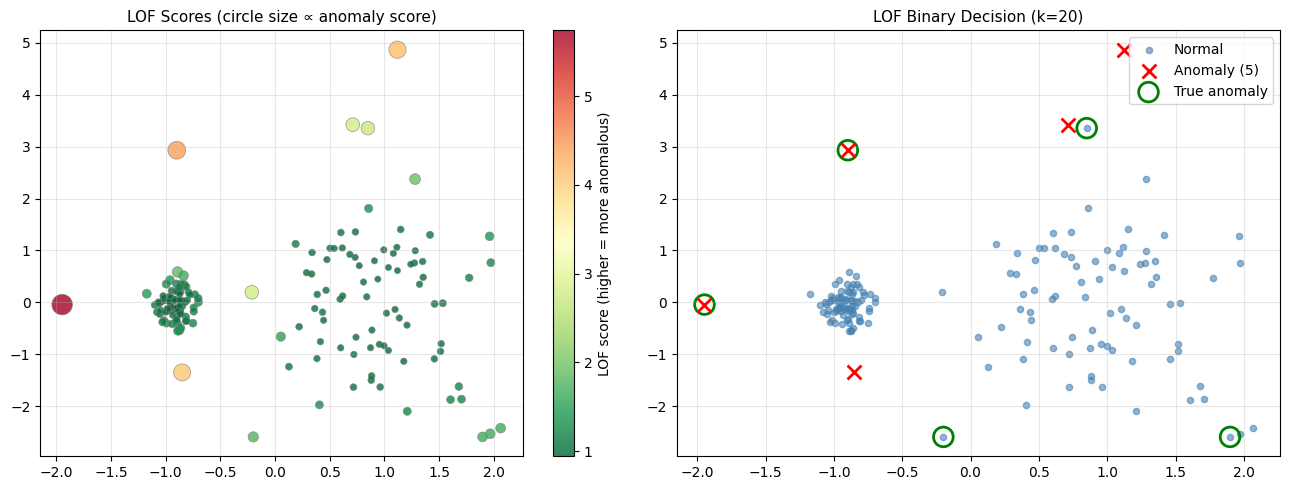

LOF — Precision: 0.400, Recall: 0.400, AUC-ROC: 0.980


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Dense cluster + sparse cluster + anomalies
cluster_dense = np.random.randn(80, 2) * 0.3 + [0, 0]
cluster_sparse = np.random.randn(80, 2) * 1.5 + [5, 0]
anomalies = np.array([[0, 3.5], [-3, 0], [5, 4], [8, -3], [2, -3]])

X_lof = np.vstack([cluster_dense, cluster_sparse, anomalies])
y_true_lof = np.array([0]*160 + [1]*5)

X_lof_s = StandardScaler().fit_transform(X_lof)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
labels_lof = lof.fit_predict(X_lof_s)
scores_lof = -lof.negative_outlier_factor_  # higher = more anomalous

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: LOF scores as circle size
ax = axes[0]
normal = labels_lof == 1
radius = (scores_lof - scores_lof.min()) / (scores_lof.max() - scores_lof.min()) * 200 + 20
sc = ax.scatter(X_lof_s[:, 0], X_lof_s[:, 1], c=scores_lof, cmap='RdYlGn_r',
                s=radius, alpha=0.8, edgecolors='gray', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='LOF score (higher = more anomalous)')
ax.set_title('LOF Scores (circle size ∝ anomaly score)', fontsize=11)
ax.grid(True, alpha=0.3)

# Right: binary decision
ax2 = axes[1]
ax2.scatter(X_lof_s[normal, 0], X_lof_s[normal, 1], c='steelblue', s=20, alpha=0.6, label='Normal')
ax2.scatter(X_lof_s[~normal, 0], X_lof_s[~normal, 1], c='red', s=100, marker='x',
            lw=2, zorder=5, label=f'Anomaly ({(~normal).sum()})')
ax2.scatter(X_lof_s[y_true_lof==1, 0], X_lof_s[y_true_lof==1, 1],
            c='none', edgecolors='green', s=200, lw=2, label='True anomaly')
ax2.set_title('LOF Binary Decision (k=20)', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lof_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

from sklearn.metrics import precision_score, recall_score, roc_auc_score
y_pred_lof = (labels_lof == -1).astype(int)
print(f"LOF — Precision: {precision_score(y_true_lof, y_pred_lof):.3f}, "
      f"Recall: {recall_score(y_true_lof, y_pred_lof):.3f}, "
      f"AUC-ROC: {roc_auc_score(y_true_lof, scores_lof):.3f}")

---
## 3. Geometric Interpretation

### Why lrd Works

Imagine drawing circles of radius = reachability distance around each point and its neighbors:

- In a **dense cluster**: circles are small → average reach-dist is small → lrd is large
- In a **sparse region**: circles are large → average reach-dist is large → lrd is small

### Why LOF = ratio of lrds

If point $A$ is in a sparse region but all its neighbors are in dense regions:
- $\text{lrd}(A)$ is small (sparse)
- $\text{lrd}(\text{neighbors})$ is large (dense)
- $\text{LOF}(A) = \frac{\text{large}}{\text{small}} >> 1$ → anomaly detected

If point $A$ is in a sparse cluster where all neighbors are also sparse:
- $\text{lrd}(A) \approx \text{lrd}(\text{neighbors})$
- $\text{LOF}(A) \approx 1$ → normal (relative to its neighborhood)

### The Reachability Distance Smoothing

The $\max(k\text{-dist}(B), d(A,B))$ smoothing has an important effect:
- For points very close together, the effective distance is floored by $B$'s k-distance
- This prevents artificially high lrd values from very small distances
- It ensures statistical stability for dense point clusters

---
## 4. Choosing k (n_neighbors)

### Effect of k

**Small k (e.g., 5)**:
- Very local density estimates
- Sensitive to local noise
- Can flag points as outliers that are just in slightly less dense sub-regions

**Large k (e.g., 50)**:
- Smoother density estimates, more global view
- More robust to local noise
- May miss fine-grained local outliers

### LOF is Stable in a Range

The original paper suggests: for well-separated clusters, LOF is largely stable for $k \in [\text{MinPts}_{\min}, \text{MinPts}_{\max}]$ where MinPts = cluster size. Typical ranges: $k \in [10, 50]$.

### Practical Guidance

- Start with `n_neighbors = 20`
- Try a range of values (10, 20, 30, 50) and pick the most consistent
- Cross-validate if you have some labeled anomalies

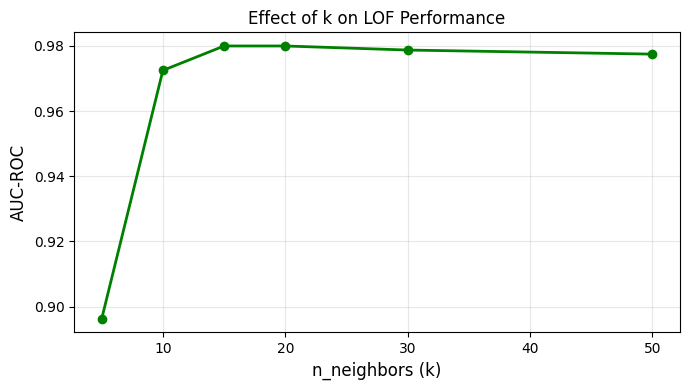

k=  5: AUC = 0.8963
k= 10: AUC = 0.9725
k= 15: AUC = 0.9800
k= 20: AUC = 0.9800
k= 30: AUC = 0.9788
k= 50: AUC = 0.9775


In [2]:
# Effect of k on LOF
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

k_values = [5, 10, 15, 20, 30, 50]
aucs = []

for k in k_values:
    lof_k = LocalOutlierFactor(n_neighbors=k, contamination=0.03)
    lof_k.fit_predict(X_lof_s)
    scores_k = -lof_k.negative_outlier_factor_
    auc = roc_auc_score(y_true_lof, scores_k)
    aucs.append(auc)

plt.figure(figsize=(7, 4))
plt.plot(k_values, aucs, 'go-', lw=2)
plt.xlabel('n_neighbors (k)', fontsize=12)
plt.ylabel('AUC-ROC', fontsize=12)
plt.title('Effect of k on LOF Performance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lof_k_effect.png', dpi=120, bbox_inches='tight')
plt.show()

for k, auc in zip(k_values, aucs):
    print(f"k={k:3d}: AUC = {auc:.4f}")

---
## 5. LOF in Novelty Detection Mode

By default, `LocalOutlierFactor` operates in **outlier detection** mode: fit and predict on the same dataset. You can't call `predict()` on new samples.

Setting `novelty=True` enables **novelty detection**: fit on training data, then `predict()` on new test data.

**Important**: In novelty mode, the training data should contain only (or mostly) normal samples. LOF will then flag test points that are anomalous relative to the training distribution.

In [3]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import numpy as np

np.random.seed(42)

# Training: only normal samples
X_train_n = np.random.randn(200, 2)  # normal

# Test: normal + anomalies
X_test_n = np.random.randn(50, 2)   # normal
X_test_a = np.random.uniform(-5, 5, (10, 2)) * 2  # anomalies
X_test_all = np.vstack([X_test_n, X_test_a])
y_test_lof = np.array([0]*50 + [1]*10)

scaler = StandardScaler()
X_train_ns = scaler.fit_transform(X_train_n)
X_test_ns = scaler.transform(X_test_all)

# novelty=True: fit on training, predict on test
lof_novelty = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.1)
lof_novelty.fit(X_train_ns)

preds_n = lof_novelty.predict(X_test_ns)  # 1=normal, -1=anomaly
scores_n = -lof_novelty.decision_function(X_test_ns)

from sklearn.metrics import precision_score, recall_score, roc_auc_score
y_pred_n = (preds_n == -1).astype(int)
print("LOF Novelty Detection Mode:")
print(f"  Precision: {precision_score(y_test_lof, y_pred_n):.3f}")
print(f"  Recall:    {recall_score(y_test_lof, y_pred_n):.3f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_lof, scores_n):.3f}")

LOF Novelty Detection Mode:
  Precision: 0.588
  Recall:    1.000
  AUC-ROC:   1.000


---
## 6. LOF vs Isolation Forest vs DBSCAN

| Aspect | LOF | Isolation Forest | DBSCAN |
|---|---|---|---|
| **Type** | Density ratio | Tree partitioning | Density threshold |
| **Output** | Continuous score | Continuous score | Hard label |
| **Local vs global** | **Local** | Global | Local (via ε) |
| **Varying density** | **Handles well** | Struggles | Struggles |
| **High dimensions** | Struggles ($d>20$) | **Works well** | Struggles |
| **Speed** | $O(n^2)$ | $O(n \log n)$ | $O(n \log n)$ |
| **Contamination needed** | Yes | Yes | **No** |
| **Predict new points** | Novelty mode | **Yes** | No (re-fit) |
| **Interpretability** | Medium | Medium | **High** |

### When to Choose LOF

- Data has clusters of **varying density** (some tight, some loose)
- Dimensionality is low to moderate (≤ 20 features)
- You want to detect **local** outliers (unusual relative to local context)
- You have enough compute time for $O(n^2)$

---
## 7. Implementation from Scratch

In [4]:
import numpy as np
from sklearn.metrics import roc_auc_score

def lof_scratch(X, k=20):
    """
    Compute LOF scores for all points in X.
    Returns array of LOF scores (higher = more anomalous).
    """
    from scipy.spatial.distance import cdist
    n = len(X)
    D = cdist(X, X, 'euclidean')  # full pairwise distances
    np.fill_diagonal(D, np.inf)   # exclude self

    # Step 1: k-distance and k-neighborhoods
    k_dist = np.sort(D, axis=1)[:, k-1]  # k-th nearest neighbor distance
    sorted_idx = np.argsort(D, axis=1)   # sorted neighbor indices
    # N_k(i): indices of k nearest neighbors (may include ties)
    N_k = [sorted_idx[i, :k] for i in range(n)]

    # Step 2: reachability distance: reach_dist(i, j) = max(k_dist(j), d(i,j))
    reach_dist = np.maximum(k_dist[None, :], D)  # shape (n, n)

    # Step 3: local reachability density
    lrd = np.array([
        len(N_k[i]) / sum(reach_dist[i, j] for j in N_k[i])
        for i in range(n)
    ])

    # Step 4: LOF score
    lof_scores = np.array([
        sum(lrd[j] for j in N_k[i]) / (len(N_k[i]) * lrd[i])
        for i in range(n)
    ])

    return lof_scores


# Test against sklearn
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(0)
X_test_lof = np.random.randn(80, 2)
X_test_lof = np.vstack([X_test_lof, np.array([[5, 5], [-4, 4], [5, -5]])])
y_test_l = np.array([0]*80 + [1]*3)

scores_scratch = lof_scratch(X_test_lof, k=10)

lof_sk = LocalOutlierFactor(n_neighbors=10, contamination=0.04)
lof_sk.fit_predict(X_test_lof)
scores_sk = -lof_sk.negative_outlier_factor_

corr = np.corrcoef(scores_scratch, scores_sk)[0, 1]
print(f"Correlation between scratch and sklearn LOF scores: {corr:.6f}")
print(f"AUC (scratch): {roc_auc_score(y_test_l, scores_scratch):.4f}")
print(f"AUC (sklearn): {roc_auc_score(y_test_l, scores_sk):.4f}")

Correlation between scratch and sklearn LOF scores: 1.000000
AUC (scratch): 1.0000
AUC (sklearn): 1.0000


---
## 8. sklearn LOF on Real Data

Method                 AUC-ROC    AUC-PR
----------------------------------------
LOF (k=5  )             0.5571    0.4275
LOF (k=10 )             0.5536    0.4276
LOF (k=20 )             0.5380    0.4151
LOF (k=40 )             0.5622    0.4187
Isolation Forest        0.8134    0.6741


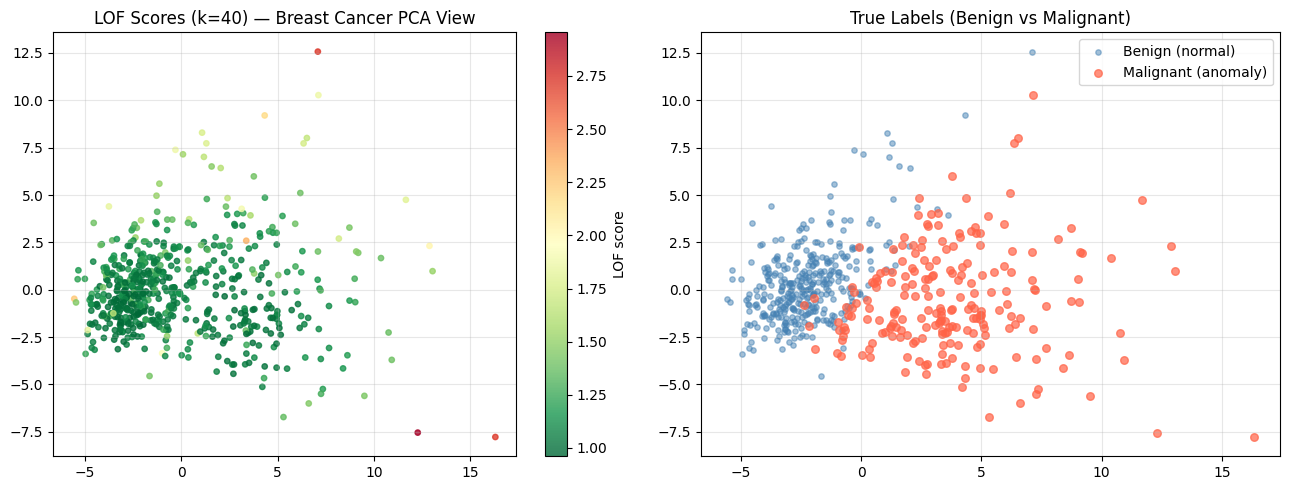

In [5]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

cancer = load_breast_cancer()
X_bc = StandardScaler().fit_transform(cancer.data)
y_bc_anom = 1 - cancer.target  # malignant=1 (anomaly), benign=0

# LOF — different k values
k_vals = [5, 10, 20, 40]
lof_results = {}
for k in k_vals:
    lof_k = LocalOutlierFactor(n_neighbors=k, contamination=y_bc_anom.mean())
    lof_k.fit_predict(X_bc)
    s = -lof_k.negative_outlier_factor_
    lof_results[k] = {'scores': s, 'auc_roc': roc_auc_score(y_bc_anom, s),
                       'auc_pr': average_precision_score(y_bc_anom, s)}

# Isolation Forest baseline
iso_bc2 = IsolationForest(n_estimators=200, contamination=y_bc_anom.mean(), random_state=42)
iso_bc2.fit(X_bc)
scores_iso2 = -iso_bc2.score_samples(X_bc)

print(f"{'Method':<20} {'AUC-ROC':>9} {'AUC-PR':>9}")
print('-' * 40)
for k in k_vals:
    r = lof_results[k]
    print(f"LOF (k={k:<3})          {r['auc_roc']:>9.4f} {r['auc_pr']:>9.4f}")
print(f"{'Isolation Forest':<20} {roc_auc_score(y_bc_anom, scores_iso2):>9.4f} "
      f"{average_precision_score(y_bc_anom, scores_iso2):>9.4f}")

# Visualize LOF scores in 2D
X_2d_bc = PCA(n_components=2).fit_transform(X_bc)
best_k = max(lof_results, key=lambda k: lof_results[k]['auc_roc'])
scores_best = lof_results[best_k]['scores']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(X_2d_bc[:, 0], X_2d_bc[:, 1], c=scores_best,
                     cmap='RdYlGn_r', s=15, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='LOF score')
axes[0].set_title(f'LOF Scores (k={best_k}) — Breast Cancer PCA View')
axes[0].grid(True, alpha=0.3)

# True anomaly labels for comparison
axes[1].scatter(X_2d_bc[y_bc_anom==0, 0], X_2d_bc[y_bc_anom==0, 1],
                c='steelblue', s=15, alpha=0.5, label='Benign (normal)')
axes[1].scatter(X_2d_bc[y_bc_anom==1, 0], X_2d_bc[y_bc_anom==1, 1],
                c='tomato', s=30, alpha=0.7, label='Malignant (anomaly)')
axes[1].set_title('True Labels (Benign vs Malignant)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lof_breast_cancer.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8.1 Experiment — Isolation Forest vs. DBSCAN vs. LOF, Same Dataset

**Hypothesis**: Isolation Forest, DBSCAN, and LOF will not fully agree on which points are anomalous, because each defines "anomalous" differently (global ease-of-isolation, a hard density threshold, and density *relative to local neighbors*, respectively). Specifically, **LOF should outperform the other two at flagging points on the boundary of a sparse-but-legitimate cluster**, since a fixed global contamination rate (Isolation Forest) and a single global ε (DBSCAN) cannot both correctly treat a tight cluster and a loose cluster as "normal" at once, while LOF's neighbor-relative comparison can.

**Setup**: build a dataset with one dense Gaussian cluster, one sparse Gaussian cluster, and injected far-away uniform-random outliers (deliberately the scenario the hypothesis targets), then run all three methods with a matched contamination/ε budget and compare AUC-ROC / AUC-PR plus a visual of which points each method flags.

Method                 AUC-ROC    AUC-PR   # Flagged
----------------------------------------------------
Isolation Forest        0.9971    0.9578          15
DBSCAN (noise)               —         —           8   (no continuous score)
LOF                     0.9731    0.6625          15

Sparse-cluster boundary points wrongly flagged as anomalies (false positives):
  Isolation Forest: 1 / 22
  DBSCAN noise:     0 / 22
  LOF:              0 / 22


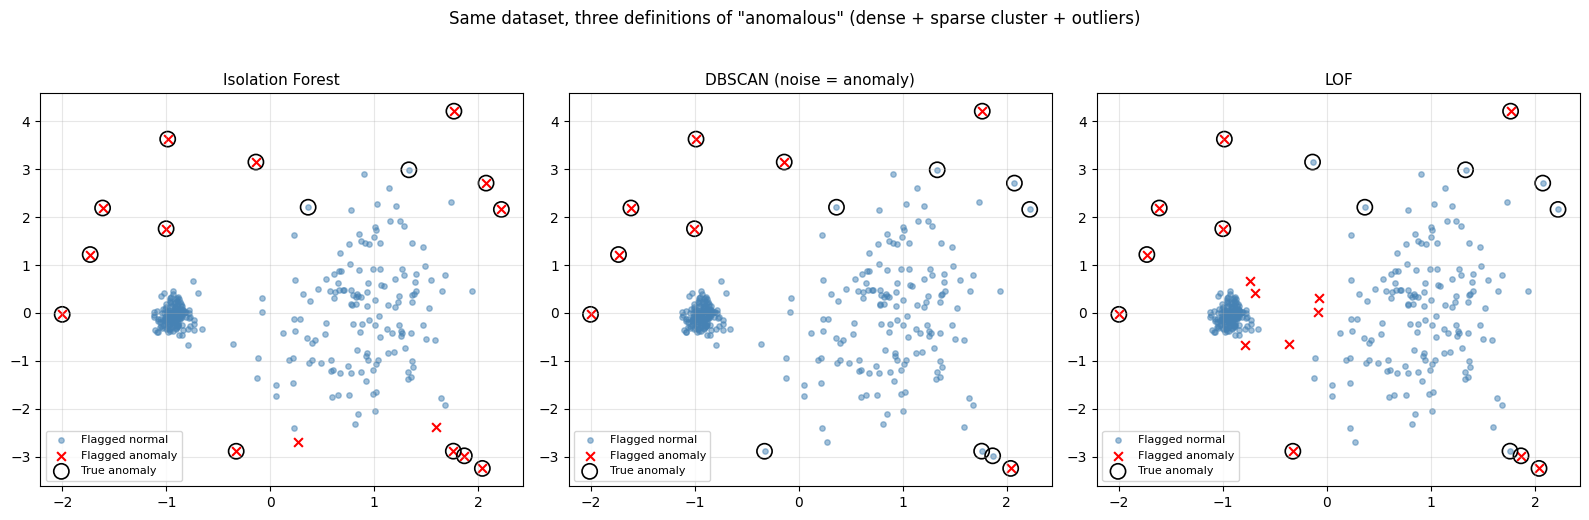

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

rng = np.random.default_rng(42)

# Dense cluster + sparse cluster + far-away uniform outliers
dense = rng.normal(loc=[0, 0], scale=0.3, size=(150, 2))
sparse = rng.normal(loc=[6, 0], scale=1.4, size=(150, 2))
outliers = rng.uniform(low=[-4, -4], high=[12, 6], size=(15, 2))

X_cmp = np.vstack([dense, sparse, outliers])
y_cmp = np.array([0] * 300 + [1] * 15)  # 1 = true anomaly
X_cmp_s = StandardScaler().fit_transform(X_cmp)
contamination = y_cmp.mean()

# --- Isolation Forest ---
iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
iso.fit(X_cmp_s)
scores_iso = -iso.score_samples(X_cmp_s)
flag_iso = iso.predict(X_cmp_s) == -1

# --- DBSCAN (eps chosen from k-distance plot elbow, min_samples rule of thumb 2*n_features) ---
nn = NearestNeighbors(n_neighbors=5).fit(X_cmp_s)
dists, _ = nn.kneighbors(X_cmp_s)
eps = np.percentile(dists[:, -1], 100 * (1 - contamination))
db = DBSCAN(eps=eps, min_samples=5)
labels_db = db.fit_predict(X_cmp_s)
flag_db = labels_db == -1

# --- LOF ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
labels_lof_cmp = lof.fit_predict(X_cmp_s)
scores_lof_cmp = -lof.negative_outlier_factor_
flag_lof = labels_lof_cmp == -1

print(f"{'Method':<20}{'AUC-ROC':>10}{'AUC-PR':>10}{'# Flagged':>12}")
print('-' * 52)
print(f"{'Isolation Forest':<20}{roc_auc_score(y_cmp, scores_iso):>10.4f}"
      f"{average_precision_score(y_cmp, scores_iso):>10.4f}{flag_iso.sum():>12}")
print(f"{'DBSCAN (noise)':<20}{'—':>10}{'—':>10}{flag_db.sum():>12}   (no continuous score)")
print(f"{'LOF':<20}{roc_auc_score(y_cmp, scores_lof_cmp):>10.4f}"
      f"{average_precision_score(y_cmp, scores_lof_cmp):>10.4f}{flag_lof.sum():>12}")

# Recall specifically on the sparse-cluster boundary region (x in [7.5, 9], the
# region the hypothesis targets: legitimate sparse-cluster edge points, not the
# injected outliers)
sparse_edge_mask = (X_cmp[:, 0] > 7.5) & (y_cmp == 0)
print(f"\nSparse-cluster boundary points wrongly flagged as anomalies (false positives):")
print(f"  Isolation Forest: {flag_iso[sparse_edge_mask].sum()} / {sparse_edge_mask.sum()}")
print(f"  DBSCAN noise:     {flag_db[sparse_edge_mask].sum()} / {sparse_edge_mask.sum()}")
print(f"  LOF:              {flag_lof[sparse_edge_mask].sum()} / {sparse_edge_mask.sum()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, flag, title in zip(axes, [flag_iso, flag_db, flag_lof],
                            ['Isolation Forest', 'DBSCAN (noise = anomaly)', 'LOF']):
    ax.scatter(X_cmp_s[~flag, 0], X_cmp_s[~flag, 1], c='steelblue', s=15, alpha=0.5, label='Flagged normal')
    ax.scatter(X_cmp_s[flag, 0], X_cmp_s[flag, 1], c='red', s=40, marker='x', lw=1.5, label='Flagged anomaly')
    ax.scatter(X_cmp_s[y_cmp == 1, 0], X_cmp_s[y_cmp == 1, 1],
               c='none', edgecolors='black', s=120, lw=1.2, label='True anomaly')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Same dataset, three definitions of "anomalous" (dense + sparse cluster + outliers)',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('anomaly_method_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Summary

### LOF Formula Chain

$$k\text{-dist}(A) \xrightarrow{\text{smooth}} \text{reach-dist}(A,B) \xrightarrow{\text{invert avg}} \text{lrd}(A) \xrightarrow{\text{ratio to neighbors}} \text{LOF}(A)$$

### Key Concepts

| Concept | Formula | What It Measures |
|---|---|---|
| k-distance | $k\text{th}$ nearest neighbor distance | Neighborhood size |
| Reach-dist | $\max(k\text{-dist}(B), d(A,B))$ | Smoothed distance |
| lrd | $k / \sum \text{reach-dist}$ | Local density |
| LOF | $\overline{\text{lrd(neighbors)}} / \text{lrd}(A)$ | Density anomaly score |

### sklearn Quick Reference
```python
from sklearn.neighbors import LocalOutlierFactor

# Outlier detection mode (fit and predict same data)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(X)            # 1=normal, -1=anomaly
scores = -lof.negative_outlier_factor_ # higher = more anomalous

# Novelty detection mode (fit on normal, predict new data)
lof_nov = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05)
lof_nov.fit(X_train)                   # fit on normal data
labels_new = lof_nov.predict(X_test)   # 1=normal, -1=anomaly
scores_new = -lof_nov.decision_function(X_test)
```